# Quartic OU with white Gaussian noise — the simplest nonlinear baseline

**Showcases:** the most elementary *nonlinear* stochastic process the pipeline handles — an Ornstein–Uhlenbeck variable with a cubic restoring force driven by **white** Gaussian noise. A single physical field, no Markovian embedding, so the diagrammatics run on the bare white-noise action and the loop integrals stay cheap (2-loop here completes in a fraction of a second). 

The SDE can be written as the negative gradient of the potential with respect to the field with additive noise.

$$\dot x = -\partial_x U(x) + \xi,\qquad \langle\xi(t)\xi(t')\rangle = 2D\,\delta(t-t'),\qquad U(x)=\tfrac{\mu}{2}x^2+\tfrac{\varepsilon}{4}x^4.$$

Explicitly, we have

$$\dot x = -\mu x - \varepsilon x^3 + \xi,\qquad \langle\xi(t)\xi(t')\rangle = 2D\,\delta(t-t').$$

At $\mu>0$ the mean-field saddle is $x^*=0$ (single well); $\mu<0$ is the genuine double well. The cubic term suppresses the equal-time variance below the linear value $D/\mu$; the loop corrections capture that shift.

## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'api' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'api')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for simulations/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the theory file `theories/ou_quartic.theory.py`. A **single** physical field $x$ with white-noise drive — note there is just one fluctuation field `dx`.

In [2]:
THEORY = 'ou_quartic'
model, mod = dd.load_theory(THEORY)
dd.describe_model(model, mod)
print('\nphysical fields:', dd.field_names(model))

────────────────────────────────────────────────────────────────────────
  OU Quartic (white noise)
────────────────────────────────────────────────────────────────────────
Domain         : temporal ODE (time-only)
Fields         : x — variable
Response fields: xt
Parameters     :
    mu = 1.0  (positive)
    eps = 0.02  (positive)
    D = 1.0  (positive)
Mean-field saddle (solved by the pipeline): xstar
Governing eqn  : (Dt+mu)*x[i] = -eps*x[i]^3
Action  S      : sum(xt[i]*((Dt+mu)*x[i] + eps*x[i]^3) - D*xt[i]^2 for i in pop)
Suggested run  : k=2, max_ell=0

The simplest nonlinear stochastic process in the framework: an
Ornstein–Uhlenbeck variable with a cubic restoring nonlinearity, driven by
*white* Gaussian noise,

    dx/dt = -mu*x - eps*x^3 + xi,    <xi(t) xi(t')> = 2 D delta(t - t').

This is the white-noise sibling of ``ou_quartic_colored`` — a SINGLE physical
field, no finite-tau_c Markovian embedding — so every diagram runs on the bare
white-noise system and the loop integral

Before evaluating anything, it helps to *see* what the pipeline sums. `dd.plot_prediagrams` draws the **contributing prediagrams** — the directed MSR-JD topologies that survive this theory's vertex/source filter — grouped by topology family, in the Buice/Ocker convention: **time flows right → left**, with noise **sources on the right** ($i, ii, \dots$), **interaction vertices in the middle** ($a, b, c, \dots$), and **external legs on the left** ($1, 2, \dots$). Each propagator carries a mid-edge arrowhead giving its direction; **propagators are named by their endpoints** (e.g. $a\to b$).

`dd.prediagram_mappings` prints the per-diagram **label map** — how those generic labels specialise to this theory's field types: source $i \to K^{(2)}$, vertex $a \to$ the interaction monomial, propagator $a\to b \to G[\phi \leftarrow \tilde\phi]$, external leg $1 \to$ the field.

Shown here at $\ell \le 1$ (tree + one-loop). Note, that for the single well case ($\mu > 0$), many diagrams become zero because all internal vertices but the degree 4 (3 in, 1 out) vertex have factors of the mean-field solution. In the double well cases, lower degree vertices contribute, and the diagrams are no longer trivial.

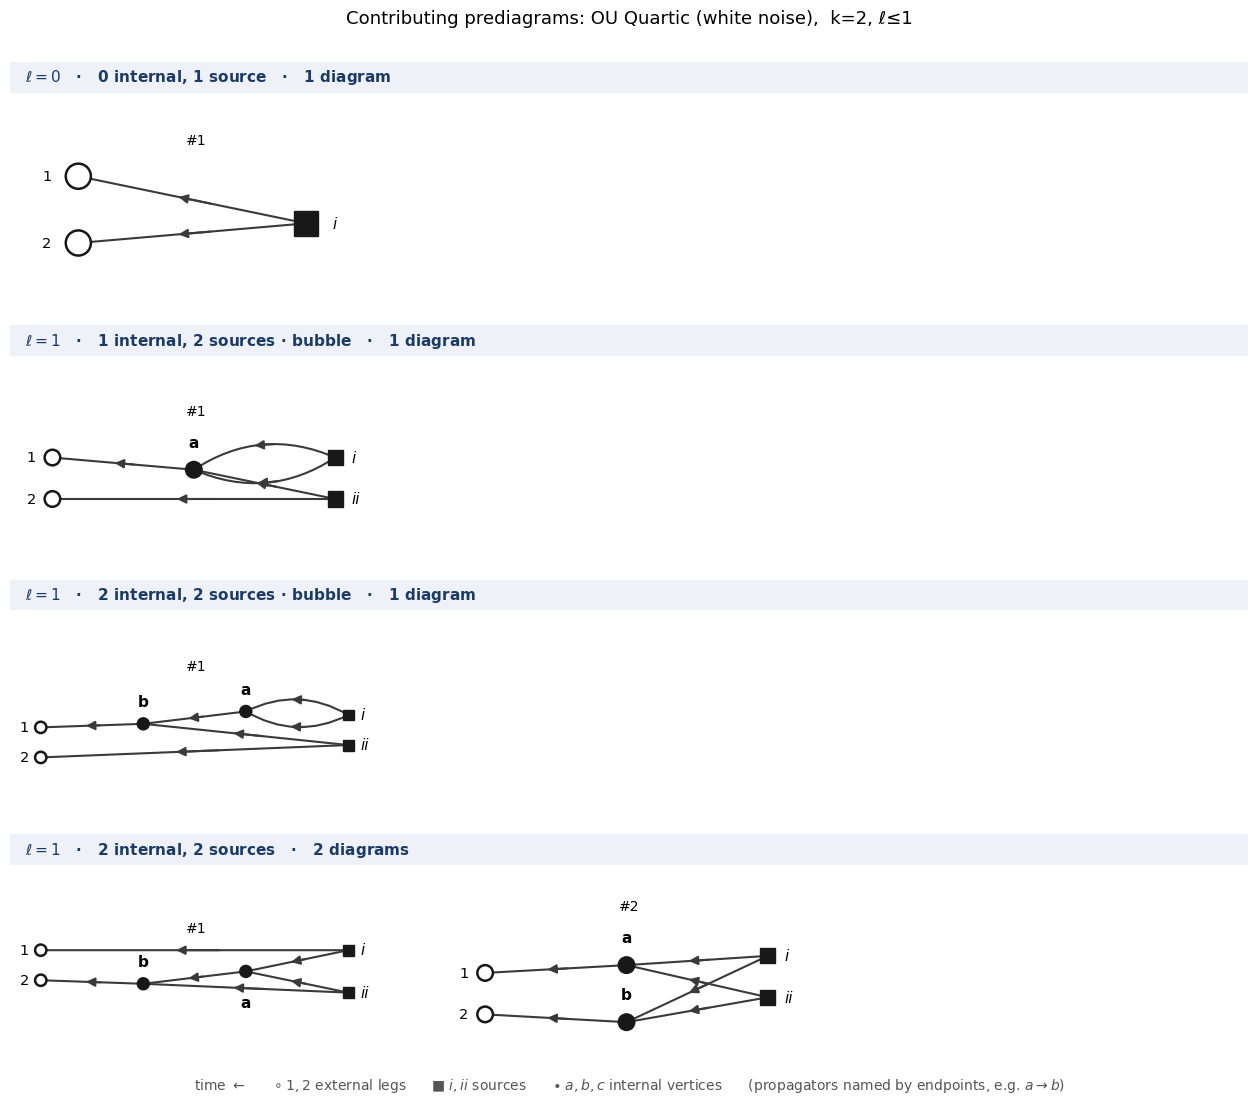

In [3]:
# Diagram topologies summed for C_xx(τ), grouped by family (tree + 1-loop).
dd.plot_prediagrams(model, k=2, max_ell=1)

In [4]:
# The label map: how each generic prediagram label specialises to this theory.
_ = dd.prediagram_mappings(model, k=2, max_ell=1)

════════════════════════════════════════════════════════════════════════
 OU Quartic (white noise) — prediagram → typed-diagram label maps  (k=2, ℓ≤1)
════════════════════════════════════════════════════════════════════════

ℓ=0 · 0 internal, 1 source · #1   (1 typing)
  ── typing 1 ──
     source i    → K^(2) ⟨xt xt⟩
     propagator i→1     → G[dx ← xt]
     propagator i→2     → G[dx ← xt]
     external legs → 1=dx, 2=dx

ℓ=1 · 1 internal, 2 sources · bubble · #1   (1 typing)
  ── typing 1 ──
     source i    → K^(2) ⟨xt xt⟩
     source ii   → K^(2) ⟨xt xt⟩
     vertex a    → coeff eps   resp⟨xt⟩ phys⟨dx dx dx⟩
     propagator a→1     → G[dx ← xt]
     propagator ii→2    → G[dx ← xt]
     propagator ii→a    → G[dx ← xt]
     propagator i→a₁    → G[dx ← xt]
     propagator i→a₂    → G[dx ← xt]
     external legs → 1=dx, 2=dx

ℓ=1 · 2 internal, 2 sources · bubble · #1   (1 typing)
  ── typing 1 ──
     source i    → K^(2) ⟨xt xt⟩
     source ii   → K^(2) ⟨xt xt⟩
     vertex a    → coeff

## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain (enumerate diagrams → propagator → mean-field saddle → loop integrals → cumulant). We request the autocorrelator $C_{xx}(\tau)=\langle x(0)\,x(\tau)\rangle$ via `external_fields=[('dx',1),('dx',1)]` and go to **2-loop** (`max_ell=2`). The plot is the **theory only** — the simulation is added in §3.

Parameters sit in the mildly-perturbative single-well regime ($\mu=1>0$, $\varepsilon=0.04$, saddle $x^*=0$): the loop expansion parameter $g_{\rm eff}\approx\varepsilon D/\mu^2=0.04$, so tree + 1-loop + 2-loop converge quickly.

In [5]:
cfg = dd.Config(
    k=2, max_ell=2,                          # C_xx(τ), tree + 1-loop + 2-loop
    external_fields=[('dx', 1), ('dx', 1)],  # physical field autocorrelator
    parameters={'mu': 1.0, 'eps': 0.04, 'D': 1.0},
    tau_grid=(-8.0, 8.0, 33),
    parallel=False,                          # serial (no fork in a notebook)
#   ─── optional · uncomment any (swap the leading # for a space) · dd.config_options() lists all ───
#   output='moment',              # 'cumulant'(default) | 'moment' | 'central_moment'
#   kpoint_base_lags=[0.0, 0.0],  # k≥3 temporal: fix the non-swept legs (slices cross here)
#   kpoint_full_grid=True,        # k≥3 temporal: full (k−1)-D tensor C(τ₁,…) vs axis slices
#   dyson_order=2, reference_diffusion=1.0,   # coupled unequal-D Dyson dressing
#   fixed_point_index=0,          # multi-root saddle: which stable root (0, 1, …)
#   mf_dae_n_starts=64, mf_dae_seed_box=None, # saddle solver: multi-start / seed box
#   n_workers=4,                  # worker count (spatial threads; macOS temporal: outside Jupyter)
#   verbose=True,                 # print backend progress
#   show_orders='incremental',    # 'cumulative'(default) | 'incremental' | 'total'
#   logy=True,                    # log-scale the y axis
#   components=None,              # which (i,j)/slice to draw (multi-field)
#   figsize=(7.5, 4.6),           # matplotlib figure size
#   title='...',                  # override the plot title
#   save='fig.png',               # path to savefig
)


theory : 'OU Quartic (white noise)'
k      : 2    max_ell : 2
fields : ['x']   spatial_dim : 0


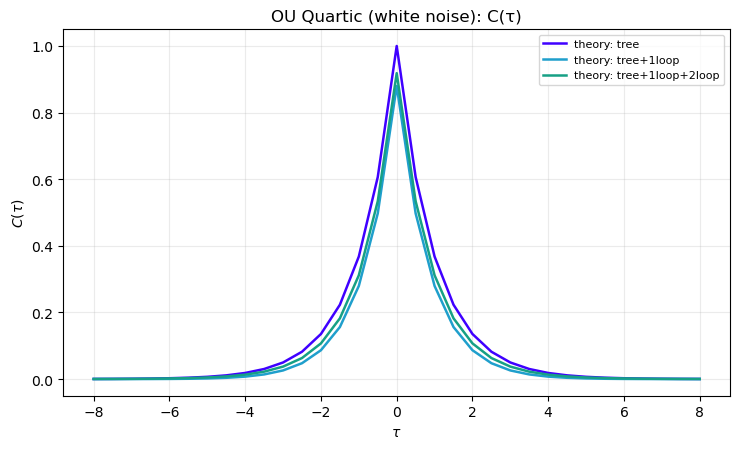

In [6]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
dd.plot_cumulant(res, cfg, model)   # theory only
plt.show()

## 3. Independent simulation

A direct Euler–Maruyama integration of the white-noise SDE — written from scratch, no reference to the diagrammatics. We integrate $x$ forward, bin it **finely** (bin width $\ll 1/\mu$, so the bin-averaged variance equals the instantaneous $C_{xx}(0)$ the theory reports), and estimate the connected $C_{xx}(\tau)$. Overlaying it on the pipeline curve is the validation.

sim took 7.4s  (3 runs × T=2e+05)
C_xx(0):  tree = 1.0000   tree+loops = 0.9184   sim = 0.9063 ± 0.0017


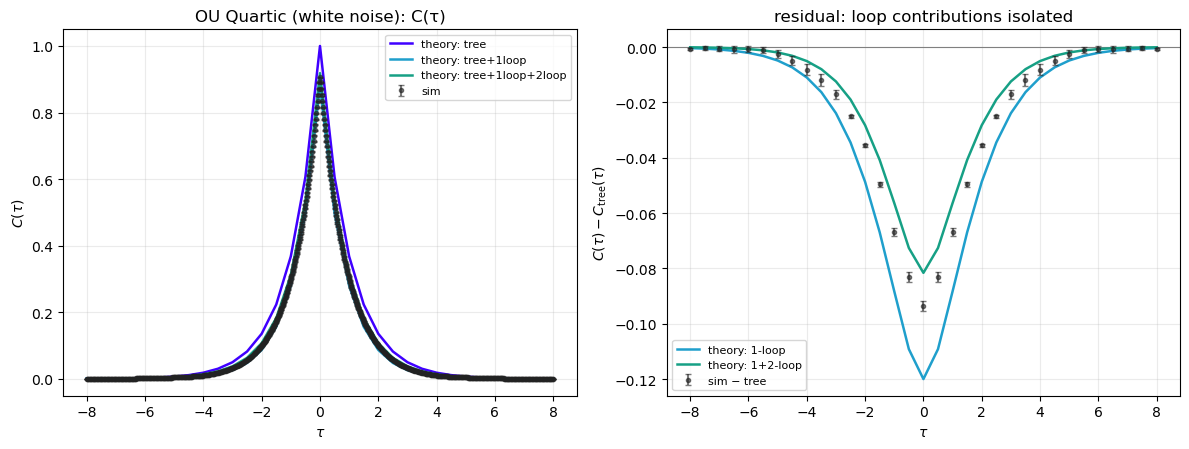

In [7]:
# Independent SDE simulation (Euler–Maruyama, white Gaussian noise) — NOT the pipeline.
from simulations.ou_langevin_sim_numba import sim_ou_quartic_numba
from simulations.cumulant_estimator import estimate_kpoint_slices
fp = res['_resolved']['parameters']          # same physics as the theory run
# Cast to plain Python floats — under the Sage kernel the resolved params are
# Sage ring elements, which numba's njit cannot type.
mu = float(fp['mu']); eps = float(fp['eps']); D = float(fp['D'])

# Discretization.  dt_sim ≪ relaxation time 1/mu; bin FINELY (dt_bin ≪ 1/mu)
# so the bin-averaged variance is effectively the instantaneous C_xx(0) — a
# coarse bin would smooth fluctuations and bias C_xx(0) low.
dt_sim, dt_bin = float(0.01), float(0.02)
T_sim          = float(2.0e5)              # ~10 s for 3 runs (numba JIT); clean error bars
N_RUNS         = int(3)
tau_max        = float(np.max(np.abs(res['tau_grid'])))
n_steps        = int(T_sim / dt_sim)
bin_size_steps = int(max(round(float(dt_bin / dt_sim)), 1))
dt_bin_eff     = float(bin_size_steps * dt_sim)
n_bins         = int(n_steps // bin_size_steps)
max_lag_bins   = int(tau_max / dt_bin_eff)
x_init         = float(0.0)

# k-aware estimator (here k=2 → a single autocorrelation slice).
k         = int(res['_resolved']['k'])
base      = list(cfg.kpoint_base_lags) if cfg.kpoint_base_lags else [0.0]*(k-1)
base_bins = [int(round(b / dt_bin_eff)) for b in base]
pop_indices = [0]*k
field_types = ['dv']*k

_ = sim_ou_quartic_numba(int(1000), dt_sim, mu, eps, D, x_init,
                         bin_size_steps, int(100), int(0))    # JIT warmup
rng_base = int(np.random.SeedSequence().generate_state(1)[0]) % (2**31)
C_runs = []
t0 = time.perf_counter()
for r in range(N_RUNS):
    x_bins = sim_ou_quartic_numba(n_steps, dt_sim, mu, eps, D, x_init,
                                  bin_size_steps, n_bins, int(rng_base + r))
    tau_sim, Cj = estimate_kpoint_slices(
        dt_bin_eff, pop_indices, field_types, base_bins,
        int(max_lag_bins), voltage_bins=x_bins)              # Cj: (k-1, n_tau)
    C_runs.append(np.asarray(Cj).real)
C_arr = np.array(C_runs)
C_sim = C_arr.mean(axis=0)
C_err = C_arr.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
sim   = {'tau': tau_sim, 'C': C_sim, 'C_err': C_err}
print('sim took %.1fs  (%d runs × T=%.0g)' % (time.perf_counter() - t0, N_RUNS, T_sim))

i0 = int(np.argmin(np.abs(np.asarray(res['tau_grid']))))
js = int(np.argmin(np.abs(tau_sim)))
C0_tree = np.real(res['C_tau_by_ell'][0])[i0]
C0_loop = np.real(res['C_tau'])[i0]
print('C_xx(0):  tree = %.4f   tree+loops = %.4f   sim = %.4f ± %.4f'
      % (C0_tree, C0_loop, C_sim[0][js], C_err[0][js]))
dd.plot_cumulant(res, cfg, model, sim=sim, residual=True)
plt.show()

## Summary

White Gaussian noise enters the MSR-JD machinery directly (the noise vertex is the local $-D\,\tilde x^2$ term), so no embedding is needed and the single field keeps the diagram count — and the loop integrals — small. The cubic nonlinearity pulls the equal-time variance $C_{xx}(0)$ below the linear value $D/\mu=1$; the tree estimate already sees most of this, and the 1- and 2-loop self-energy corrections move it onto the direct simulation. Swapping `parameters` toward $\mu\to0$ (or $\mu<0$) stresses the perturbative series; the $\mu<0$ **double well** — and how the pipeline selects a stable saddle — is taken up in §4 below.

## 4. The nonzero saddle at one loop — stability and fixed-point selection

Sections 1–3 stayed in the single-well regime ($\mu>0$, mean-field saddle $x^*=0$).
At **$\mu<0$** the same quartic potential $U(x)=\tfrac{\mu}{2}x^2+\tfrac{\varepsilon}{4}x^4$
is a **double well**, and the mean-field equation

$$\mu\,x^* + \varepsilon\,(x^*)^3 = 0$$

has three roots — the barrier top $x^*=0$ and the two wells $x^*=\pm\sqrt{-\mu/\varepsilon}$.

We reload the theory as `ou_quartic_double_well` — the *same* $x^4$ action but with
**`stability_analysis` enabled** — so `dd.run` returns *every* real root together with its
**linear stability** (the eigenvalues of the fluctuation operator
$A=\partial_x(\text{drift})\big|_{x^*}$, exposed as `mf_all_roots`, `mf_stable_roots`,
`mf_unstable_roots`). The pipeline keeps only **stable** fixed points — the barrier top has
negative curvature $U''=\mu<0$ and is discarded — and `Config.fixed_point_index=0` expands
the loops about the **lowest** stable one, the most-negative well $x^*=-\sqrt{-\mu/\varepsilon}$.

Here $\mu=-1,\ \varepsilon=0.1$ put the wells at $x^*=\pm\sqrt{10}\approx\pm3.16$; with $D=0.1$
the barrier $\Delta U=2.5$ is deep ($\Delta U/D\approx25$), so a trajectory launched in one
well stays **trapped** there — the single-saddle loop expansion is valid, and the simulation
below can sit in the same well.

Mean-field roots  μ·x* + ε·x*³ = 0   (μ=-1, ε=0.1)   and their stability:
    x* = -3.1623   STABLE     eigenvalue(s): [-2.]
    x* = +0.0000   unstable   eigenvalue(s): [1.]
    x* = +3.1623   STABLE     eigenvalue(s): [-2.]

  stable fixed points          : [-3.162277660168315, 3.1622776601683666]
  chosen (fixed_point_index=0) : x* = -3.1623   (lowest stable, root #0)
  → the one-loop C_xx(τ) below is the expansion about x* = -3.1623


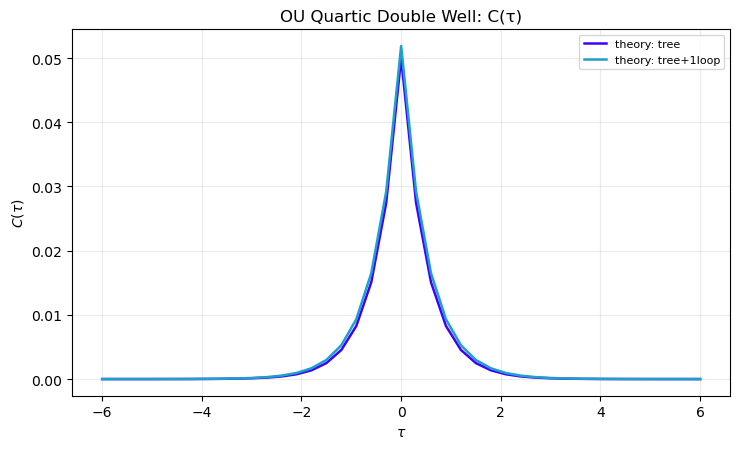

In [8]:
# Reload the quartic OU in its DOUBLE-WELL regime: ou_quartic_double_well is the
# same x^4 action with stability_analysis enabled, so dd.run reports every
# mean-field root together with its linear stability.
dw, dwmod = dd.load_theory('ou_quartic_double_well')
dw_cfg = dd.Config(
    k=2, max_ell=1,                              # C_xx(τ) about the nonzero saddle: tree + 1-loop
    external_fields=[('dx', 1), ('dx', 1)],
    parameters={'mu': -1.0, 'eps': 0.1, 'D': 0.1},   # double well; wells at x* = ±√10 ≈ ±3.16
    fixed_point_index=0,                         # 0 = LOWEST stable root (most negative well)
    tau_grid=(-6.0, 6.0, 41),
    parallel=False,
)
dw_res = dd.run(dw, dw_cfg, dwmod)

# Mean-field roots and their linear stability.
print('Mean-field roots  μ·x* + ε·x*³ = 0   (μ=-1, ε=0.1)   and their stability:')
for r in dw_res['mf_all_roots']:
    xs = float(np.atleast_1d(r['values']['xstar'])[0])
    ev = np.atleast_1d(r['eigenvalues_finite']).real
    print(f'    x* = {xs:+.4f}   {"STABLE  " if r["stable"] else "unstable"}   eigenvalue(s): {ev}')
stable = [float(np.atleast_1d(r['xstar'])[0]) for r in dw_res['mf_stable_roots']]
chosen = float(np.atleast_1d(dw_res['mf_values']['xstar'])[0])
print(f'\n  stable fixed points          : {stable}')
print(f'  chosen (fixed_point_index=0) : x* = {chosen:+.4f}   (lowest stable, root #{dw_res["mf_index_used"]})')
print(f'  → the one-loop C_xx(τ) below is the expansion about x* = {chosen:+.4f}')

dd.plot_cumulant(dw_res, dw_cfg, dw)            # theory: tree + 1-loop about the nonzero saddle
plt.show()

The roots above confirm the structure: $x^*=0$ is **unstable** (a barrier top,
$U''=\mu<0$, so the fluctuation operator has a positive eigenvalue), while both wells
$x^*=\pm\sqrt{10}$ are stable ($U''=\mu+3\varepsilon x^{*2}=-1+3=+2$). `fixed_point_index=0`
selects the **lowest** stable root, $x^*=-\sqrt{10}\approx-3.16$, and the one-loop
$C_{xx}(\tau)$ above is the expansion about it.

Because the saddle is now **nonzero**, the lower-degree interaction vertices — which carry
factors of $x^*$ and so vanished identically in the §1 single-well prediagrams ($x^*=0$) —
now contribute (e.g. the cubic $U'''=6\varepsilon x^*$ vertex). The one-loop resummation here
is therefore richer than the single-well case at the same loop order.

### Validation — a trapped simulation

To check the one-loop expansion about the nonzero saddle, we run a direct Euler–Maruyama
simulation **launched in the chosen well** ($x^*=-\sqrt{10}$). The deep barrier keeps it
trapped (no inter-well hopping), so the **connected** correlator
$C_{xx}(\tau)=\langle\delta x(t)\,\delta x(t{+}\tau)\rangle$ — fluctuations about the trapped
mean — is exactly the single-well object the diagrams resum. Subtracting the trapped mean is
what makes it the *connected* cumulant the theory computes.

stayed in one well : True   (⟨x⟩ ≈ -3.138 vs saddle x* = -3.162)
connected C_xx(0):  tree = 0.0500   tree+1-loop = 0.0519   sim = 0.0521 ± 0.0001


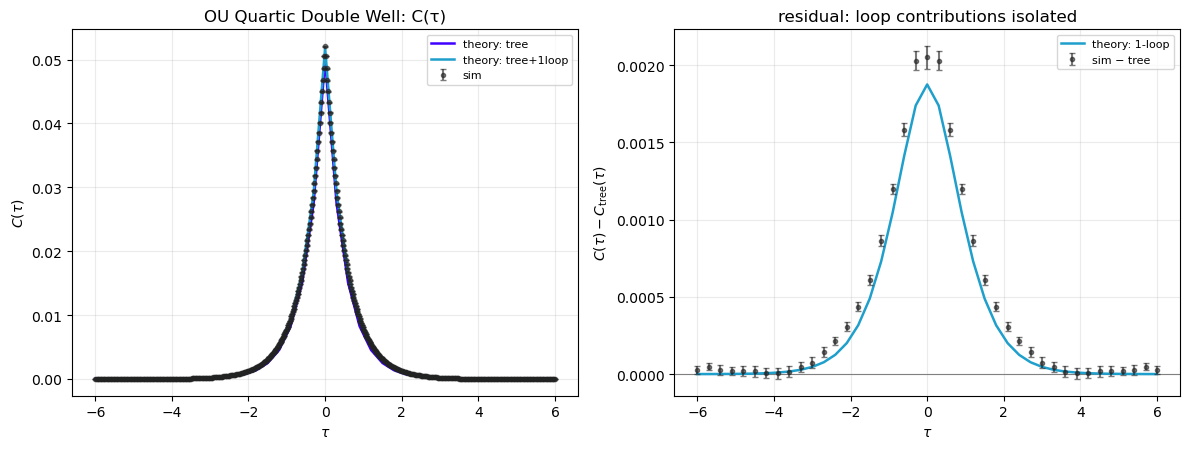

In [9]:
# Independent SDE simulation, TRAPPED in the well the theory expanded about.
from simulations.ou_langevin_sim_numba import sim_ou_quartic_numba
from simulations.cumulant_estimator import estimate_kpoint_slices
dwfp = dw_res['_resolved']['parameters']
mu_d = float(dwfp['mu']); eps_d = float(dwfp['eps']); D_d = float(dwfp['D'])
x_well = float(np.atleast_1d(dw_res['mf_values']['xstar'])[0])   # launch IN the chosen well (-√10)

dt_sim, dt_bin = float(0.01), float(0.02)
T_sim, N_RUNS  = float(2.0e5), int(6)
tau_max        = float(np.max(np.abs(dw_res['tau_grid'])))
n_steps        = int(T_sim / dt_sim)
bin_size_steps = int(max(round(dt_bin / dt_sim), 1))
dt_bin_eff     = float(bin_size_steps * dt_sim)
n_bins         = int(n_steps // bin_size_steps)
max_lag_bins   = int(tau_max / dt_bin_eff)

_ = sim_ou_quartic_numba(int(1000), dt_sim, mu_d, eps_d, D_d, x_well,
                         bin_size_steps, int(100), int(0))                # JIT warmup
rng = int(np.random.SeedSequence().generate_state(1)[0]) % (2**31)
C_runs, trapped = [], True
for run in range(N_RUNS):
    xb = sim_ou_quartic_numba(n_steps, dt_sim, mu_d, eps_d, D_d, x_well,
                              bin_size_steps, n_bins, int(rng + run))
    trapped &= bool(xb.max() < 0.0)                                      # never crossed the barrier at 0
    tau_sim, Cj = estimate_kpoint_slices(dt_bin_eff, [0, 0], ['dv', 'dv'], [0],
                                         int(max_lag_bins), voltage_bins=xb - xb.mean())  # connected
    C_runs.append(np.asarray(Cj).real)
C_arr = np.array(C_runs)
sim = {'tau': tau_sim, 'C': C_arr.mean(0), 'C_err': C_arr.std(0, ddof=1) / np.sqrt(N_RUNS)}

i0 = int(np.argmin(np.abs(np.asarray(dw_res['tau_grid'])))); js = int(np.argmin(np.abs(tau_sim)))
print('stayed in one well :', trapped, '  (⟨x⟩ ≈ %.3f vs saddle x* = %.3f)' % (float(xb.mean()), x_well))
print('connected C_xx(0):  tree = %.4f   tree+1-loop = %.4f   sim = %.4f ± %.4f'
      % (np.real(dw_res['C_tau_by_ell'][0])[i0], np.real(dw_res['C_tau'])[i0],
         sim['C'][0][js], sim['C_err'][0][js]))
dd.plot_cumulant(dw_res, dw_cfg, dw, sim=sim, residual=True)   # theory (tree + 1-loop) vs trapped simulation
plt.show()

### Making the one-loop visible

The two panels above tell the story. On the **left**, the **tree** and **tree + 1-loop**
curves sit almost on top of each other: at these parameters the one-loop correction is only
~4 % of the tree ($g_{\rm eff}\equiv D\varepsilon/\mu^2 = 0.01$), so the loop *looks*
negligible. But that is a **visibility** problem, not a significance one — the simulation
already resolves it at **tens of σ**. The **right** panel proves it: subtract the tree from
both theory and simulation and the one-loop contribution becomes the *whole* signal, with the
simulated residual $C_{xx}(\tau)-C_{\rm tree}(\tau)$ landing on it.

Could we just make the loop bigger? Only so far. A larger one-loop needs a larger
$g_{\rm eff}=D\varepsilon/\mu^2$, but for this symmetric double well the loop strength and the
trap depth are *reciprocally locked*,

$$g_{\rm eff}\cdot\frac{\Delta U}{D}=\frac14,\qquad \Delta U=\frac{\mu^2}{4\varepsilon},$$

so a bigger loop necessarily means a shallower barrier. A sweep at $\mu=-1$ confirms it:
$D=0.15$ ($g_{\rm eff}=0.015$, loop 5.6 %) still traps cleanly, but by $D\gtrsim0.2$
($\Delta U/D\lesssim12$) the trajectory hops between wells and the measured variance blows up.
Isolating the loop (the right panel) is therefore the reliable way to see it.